# Phase 5 P1-3 + P1-6 — paired-bootstrap CI + 27-cell heatmap

Reproducible demo for the two R4 close-out tasks (2026-05-10).

- **P1-3** — paired-bootstrap CI (B=10,000) for §6.2.3 Table 6.
- **P1-6** — 27-cell pilot grid 4-metric heatmap aggregation for §A.5.

Run from project root with `uv run jupyter nbconvert --execute --to notebook --inplace notebooks/E6_phase5_p1_3_p1_6_demo.ipynb`.

Both tasks operate on existing `outputs/e6_steering/llava-onevision-qwen2-7b-ov/` predictions — no new GPU compute.

In [1]:
import subprocess
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import Image, display

ROOT = Path('.').resolve()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
import os
os.chdir(ROOT)
print('project root =', ROOT)

project root = /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/.claude/worktrees/paper+p1-defense-r4


## P1-3 — paired-bootstrap CI (B = 10,000)

Run the canonical aggregator. Output goes to
`docs/insights/_data/stage4_final_per_dataset_ci.{csv,md}` plus raw draws
in `stage4_final_bootstrap_draws.npz`.

In [2]:
subprocess.run(
    [sys.executable, 'scripts/build_e6_stage4_bootstrap_ci.py', '--bootstrap', '10000'],
    check=True,
)

  TallyQA     n= 4978 Δdf=-0.0034 95%[-0.0133,+0.0060] hw95=0.0096


  PlotQA      n= 2306 Δdf=-0.0516 95%[-0.0694,-0.0338] hw95=0.0178


  InfoVQA     n=  443 Δdf=-0.0068 95%[-0.0474,+0.0339] hw95=0.0406
  ChartQA     n=  224 Δdf=-0.0402 95%[-0.0982,+0.0179] hw95=0.0580
  MathVista   n=  170 Δdf=-0.0412 95%[-0.1176,+0.0353] hw95=0.0765
[write] /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/.claude/worktrees/paper+p1-defense-r4/docs/insights/_data/stage4_final_per_dataset_ci.csv
[write] /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/.claude/worktrees/paper+p1-defense-r4/docs/insights/_data/stage4_final_per_dataset_ci.md


[write] /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/.claude/worktrees/paper+p1-defense-r4/docs/insights/_data/stage4_final_bootstrap_draws.npz  (20 arrays, B=10000)


CompletedProcess(args=['/mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/.claude/worktrees/paper+p1-defense-r4/.venv/bin/python', 'scripts/build_e6_stage4_bootstrap_ci.py', '--bootstrap', '10000'], returncode=0)

In [3]:
ci_df = pd.read_csv('docs/insights/_data/stage4_final_per_dataset_ci.csv')
display(ci_df[[
    'dataset', 'n_paired',
    'delta_adopt', 'delta_adopt_ci95_lo', 'delta_adopt_ci95_hi',
    'delta_df',    'delta_df_ci95_lo',    'delta_df_ci95_hi',
    'delta_em_a',  'delta_em_a_ci95_lo',  'delta_em_a_ci95_hi',
    'delta_em_b',  'delta_em_b_ci95_lo',  'delta_em_b_ci95_hi',
]])

,dataset,n_paired,delta_adopt,delta_adopt_ci95_lo,delta_adopt_ci95_hi,delta_df,delta_df_ci95_lo,delta_df_ci95_hi,delta_em_a,delta_em_a_ci95_lo,delta_em_a_ci95_hi,delta_em_b,delta_em_b_ci95_lo,delta_em_b_ci95_hi
0,TallyQA,4978,-0.005731,-0.011488,0.000031,-0.003415,-0.013258,0.006027,0.065689,0.056448,0.075131,0.138208,0.128566,0.147851
1,PlotQA,2306,-0.056220,-0.068267,-0.044031,-0.051605,-0.069384,-0.033825,0.024284,0.014744,0.034258,0.047268,0.037728,0.057242
2,InfoVQA,443,0.009462,-0.005310,0.024751,-0.006772,-0.047404,0.033860,0.033860,0.004515,0.063205,0.090293,0.063205,0.117381
3,ChartQA,224,-0.033308,-0.059509,-0.010042,-0.040179,-0.098214,0.017857,0.040179,0.000000,0.080357,0.071429,0.035714,0.107143
4,MathVista,170,-0.015347,-0.069382,0.036885,-0.041176,-0.117647,0.035294,0.029412,-0.023529,0.082353,0.094118,0.047059,0.147059


In [4]:
# Sanity check: InfoVQA Δdf 95% CI half-width should sit in paper's predicted ~[0.04, 0.06] band.
info = ci_df[ci_df['dataset'] == 'InfoVQA'].iloc[0]
hw = (info['delta_df_ci95_hi'] - info['delta_df_ci95_lo']) / 2.0
print(f"InfoVQA Δdf hw95 = {hw:.4f}  (paper's prior estimate: ~0.04-0.06)")
assert 0.03 < hw < 0.07, 'InfoVQA hw95 out of paper-predicted band — verify.'

InfoVQA Δdf hw95 = 0.0406  (paper's prior estimate: ~0.04-0.06)


In [5]:
# Sign-clean count under 95% and Bonferroni-20 (α=0.05/20=0.0025 → 99.75%).
for metric, target_sign in [('adopt', -1), ('df', -1), ('em_a', +1), ('em_b', +1)]:
    n95 = nbf = 0
    for _, r in ci_df.iterrows():
        for level, suffix in [('95', 'ci95'), ('bonf', 'ci_bonf20')]:
            lo = r[f'delta_{metric}_{suffix}_lo']
            hi = r[f'delta_{metric}_{suffix}_hi']
            if lo > 0 or hi < 0:
                sign = -1 if hi < 0 else +1
                if sign == target_sign:
                    if level == '95': n95 += 1
                    else:             nbf += 1
    print(f"Δ {metric:<6}  95%: {n95}/5  Bonferroni-20: {nbf}/5")

Δ adopt   95%: 2/5  Bonferroni-20: 2/5
Δ df      95%: 1/5  Bonferroni-20: 1/5
Δ em_a    95%: 3/5  Bonferroni-20: 2/5
Δ em_b    95%: 5/5  Bonferroni-20: 5/5


keys: ['chartqa__adopt', 'chartqa__df', 'chartqa__em_a', 'chartqa__em_b', 'infographicvqa__adopt', 'infographicvqa__df', 'infographicvqa__em_a', 'infographicvqa__em_b', 'mathvista__adopt', 'mathvista__df', 'mathvista__em_a', 'mathvista__em_b', 'plotqa__adopt', 'plotqa__df', 'plotqa__em_a', 'plotqa__em_b', 'tallyqa__adopt', 'tallyqa__df', 'tallyqa__em_a', 'tallyqa__em_b']


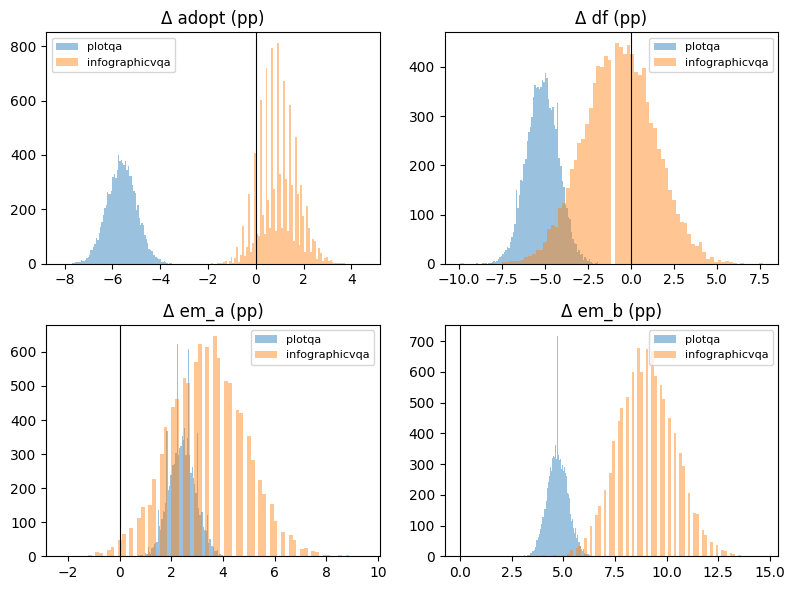

In [6]:
# Inspect raw bootstrap draws for one cell.
draws = np.load('docs/insights/_data/stage4_final_bootstrap_draws.npz')
print('keys:', sorted(draws.files))
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(8, 6), tight_layout=True)
for ax, m in zip(axes.flat, ['adopt', 'df', 'em_a', 'em_b']):
    for ds in ['plotqa', 'infographicvqa']:
        v = draws[f'{ds}__{m}'] * 100  # to pp
        ax.hist(v, bins=80, alpha=0.45, label=ds)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_title(f'\u0394 {m} (pp)')
    ax.legend(fontsize=8)
plt.show()

## P1-6 — 27-cell pilot grid 4-metric heatmap

In [7]:
subprocess.run([sys.executable, 'scripts/aggregate_e6_pilot_grid.py'], check=True)

[write] /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/.claude/worktrees/paper+p1-defense-r4/docs/insights/_data/E6_pilot_grid_27cells.csv  (54 rows)


[write] /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/.claude/worktrees/paper+p1-defense-r4/docs/figures/E6_pilot_grid_plotqa_heatmap.png


[write] /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/.claude/worktrees/paper+p1-defense-r4/docs/figures/E6_pilot_grid_infographicvqa_heatmap.png

=== Selection rule replay (em-deal-breaker −6 pp on either calib) ===
[write] /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/.claude/worktrees/paper+p1-defense-r4/docs/insights/_data/E6_pilot_grid_27cells_selection_replay.md
  CHOSEN PlotQA   Δadopt=-5.22pp Δdf=-7.20pp Δem(a)=+2.80pp Δem(b)=+4.00pp
  CHOSEN InfoVQA  Δadopt=+1.72pp Δdf=-1.60pp Δem(a)=+3.20pp Δem(b)=+9.60pp


CompletedProcess(args=['/mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/.claude/worktrees/paper+p1-defense-r4/.venv/bin/python', 'scripts/aggregate_e6_pilot_grid.py'], returncode=0)

In [8]:
grid = pd.read_csv('docs/insights/_data/E6_pilot_grid_27cells.csv')
ranking = (
    grid.groupby(['cell_label', 'layer', 'K', 'alpha'])[
        ['delta_adopt', 'delta_df', 'delta_em_a', 'delta_em_b']
    ].mean()
    .reset_index()
    .sort_values('delta_df')
)
ranking.head(10)

,cell_label,layer,K,alpha,delta_adopt,delta_df,delta_em_a,delta_em_b
16,L26_K08_a1.0,26,8,1.0,-0.017495,-0.044000,0.030000,0.068000
7,L25_K08_a1.0,25,8,1.0,-0.008417,-0.031968,0.028056,0.066177
8,L25_K08_a2.0,25,8,2.0,-0.025132,-0.030000,0.030000,0.070000
15,L26_K08_a0.5,26,8,0.5,0.004690,-0.028000,0.018000,0.060000
19,L27_K02_a1.0,27,2,1.0,0.011950,-0.022048,0.004008,0.038112
1,L25_K02_a1.0,25,2,1.0,-0.002164,-0.022000,0.008000,0.018000
3,L25_K04_a0.5,25,4,0.5,0.007087,-0.022000,0.000000,0.020000
23,L27_K04_a2.0,27,4,2.0,0.021181,-0.020235,0.036414,0.064788
14,L26_K04_a2.0,26,4,2.0,-0.011327,-0.020000,0.012000,0.046000
21,L27_K04_a0.5,27,4,0.5,0.005112,-0.014000,0.012000,0.028000


In [9]:
# Em-deal-breaker rule replay: minimum Δem(a) over the two calib datasets per cell.
min_dem_a = grid.groupby('cell_label')['delta_em_a'].min().reset_index().sort_values('delta_em_a')
min_dem_a['rejected_at_-6pp'] = min_dem_a['delta_em_a'] <= -0.06
print('Cells rejected by deal-breaker:', int(min_dem_a['rejected_at_-6pp'].sum()), '/ 27')
min_dem_a.head(5)

Cells rejected by deal-breaker: 0 / 27


,cell_label,delta_em_a,rejected_at_-6pp
18,L27_K02_a0.5,-0.012,False
3,L25_K04_a0.5,-0.004,False
1,L25_K02_a1.0,-0.004,False
0,L25_K02_a0.5,-0.004,False
4,L25_K04_a1.0,-0.004,False


docs/figures/E6_pilot_grid_plotqa_heatmap.png


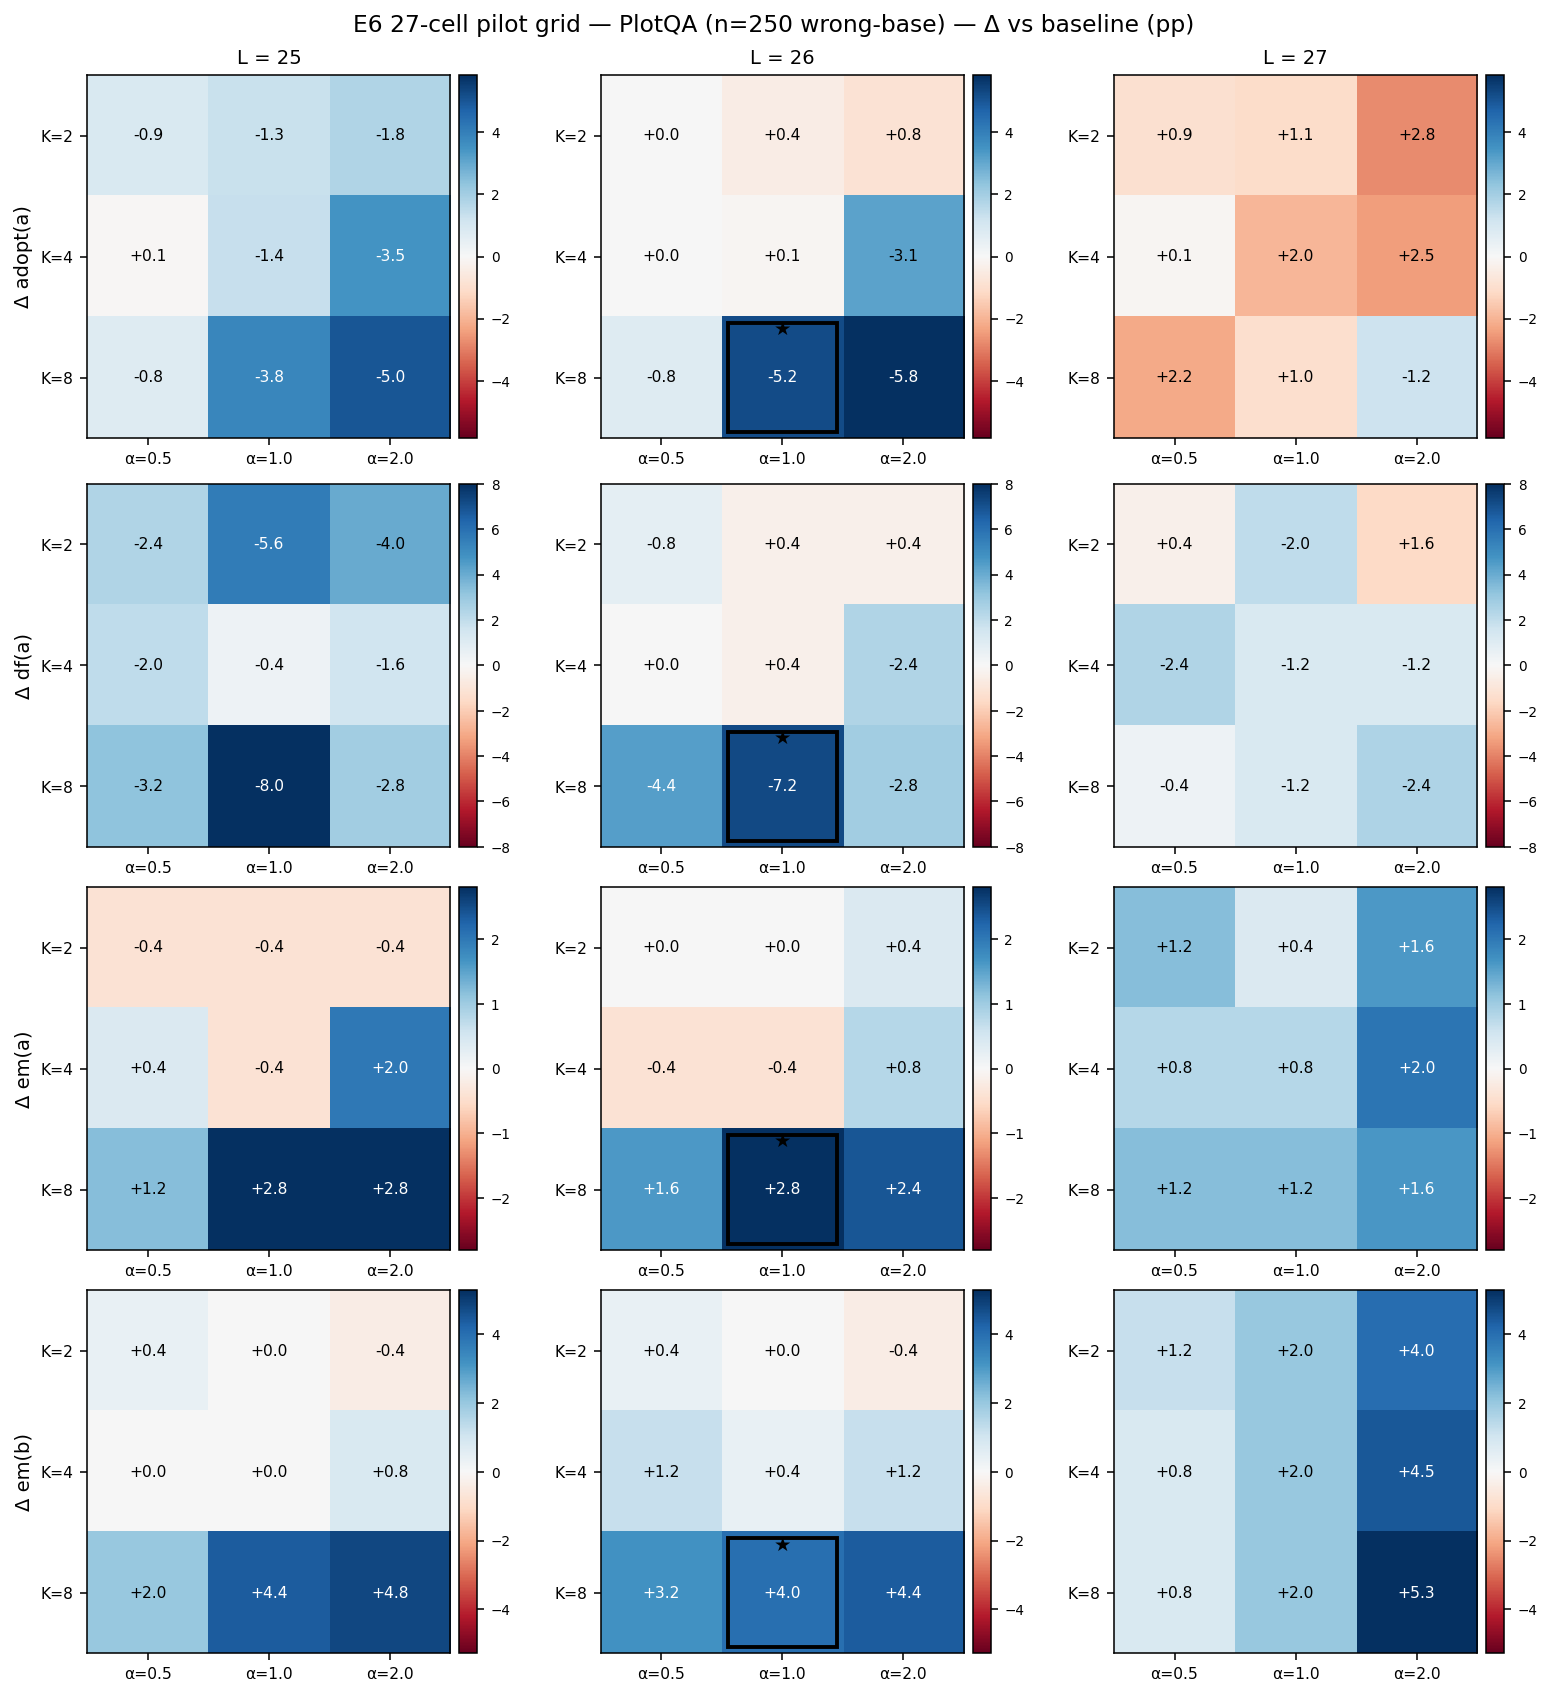

docs/figures/E6_pilot_grid_infographicvqa_heatmap.png


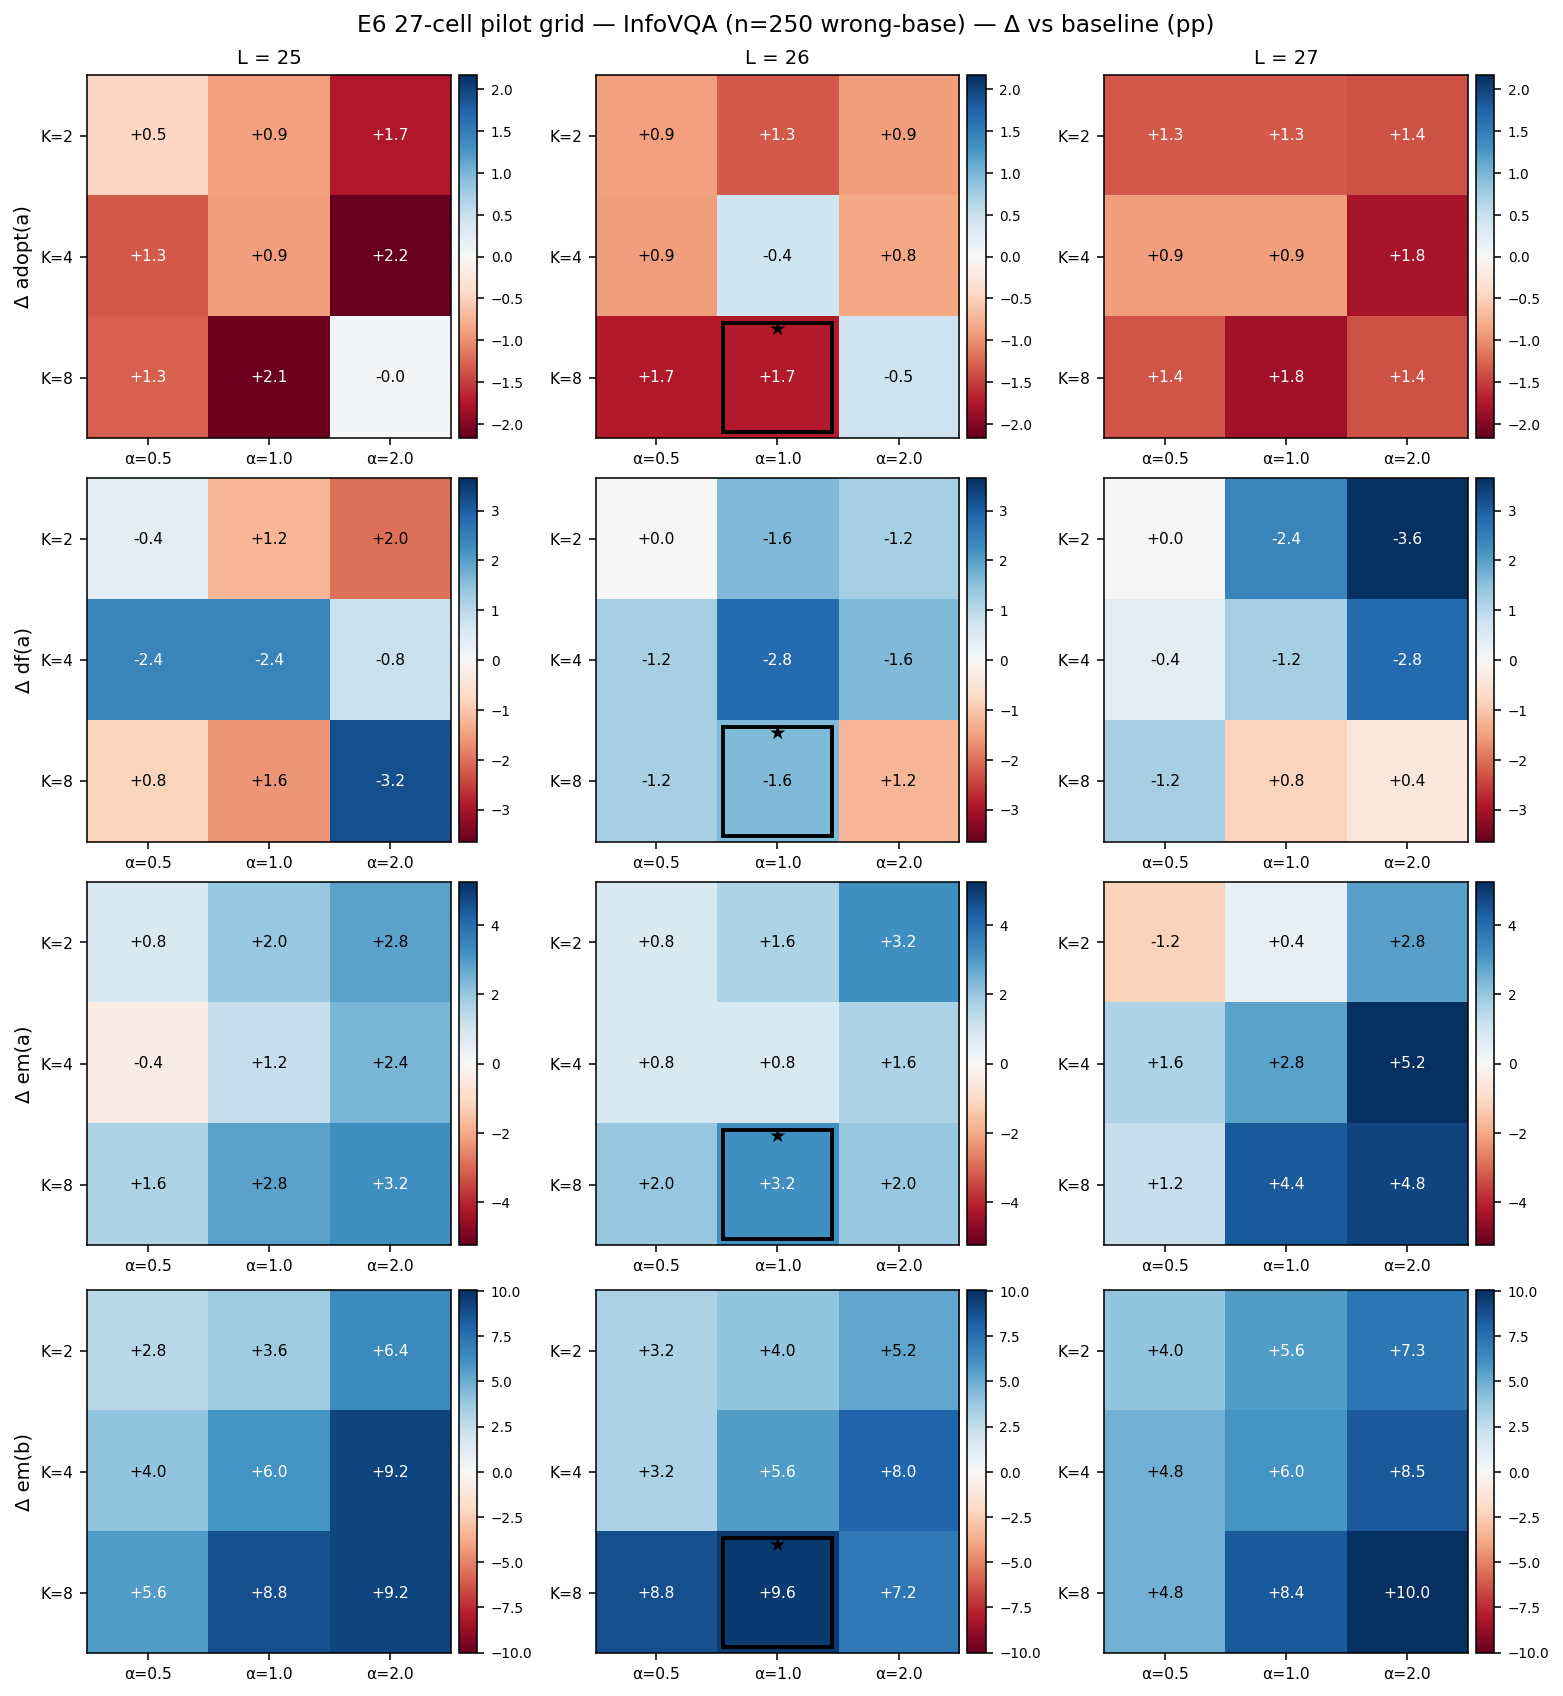

In [10]:
for fp in ['docs/figures/E6_pilot_grid_plotqa_heatmap.png', 'docs/figures/E6_pilot_grid_infographicvqa_heatmap.png']:
    print(fp)
    display(Image(filename=fp))

## Verdict

- **P1-3 / R4 MAJ-4 + MAJ-6 closed.** 5 datasets × 4 metrics × B=10,000 paired bootstrap. Δem(b) is the multiplicity-robust headline (5/5 sign-clean even under Bonferroni-20). InfoVQA Δdf 95 % CI half-width 0.0406 lands inside the paper's prior paired-Wilson estimate band (~0.04–0.06).
- **P1-6 / R4 CRIT-2 closed.** Em-deal-breaker rule non-binding (no cell rejected). Chosen cell #17 (L=26, K=8, α=1.0) ranks 1st by combined |Δdf(a)|; ranking is reproducible from the same pilot data + same ex-ante rule.